In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

In [8]:
# 1. Load data
data = pd.read_csv('/workspaces/BlizzardX/Data/feature_data1.csv')

# 2. Convert 'DATE' to datetime
data['DATE'] = pd.to_datetime(data['DATE'])

# 3. Fix 'Season' (text to numeric)
season_mapping = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
data['Season'] = data['Season'].map(season_mapping)

# 4. Sort by date (important!)
data = data.sort_values('DATE').reset_index(drop=True)

In [9]:
# 4. Train-Test Split based on last 6 months
cutoff_date = data['DATE'].max() - pd.DateOffset(months=6)

train_data = data[data['DATE'] <= cutoff_date]
test_data = data[data['DATE'] > cutoff_date]

print(f"Train Size: {train_data.shape}")
print(f"Test Size: {test_data.shape}")

Train Size: (53101, 46)
Test Size: (905, 46)


In [10]:
# 5. Features and Target
target = 'TMIN'
# Drop non-feature columns
non_features = ['DATE', 'TMIN', 'Station_ID', 'NAME', 'Station_Location']
features = [col for col in data.columns if col not in non_features]

In [11]:
X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

In [12]:
# 6. Cross-validation for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_model = xgb.XGBRegressor(random_state=42)

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


In [13]:
# 7. Train final model
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, ...)

In [14]:

# 8. Predict on unseen Test Set (Backtesting)
y_pred = final_model.predict(X_test)

In [16]:
# 9. Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n✅ Model Performance on Unseen Test Set (Backtesting):")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


✅ Model Performance on Unseen Test Set (Backtesting):
MAE: 0.27
RMSE: 0.35
MSE: 0.12
R² Score: 1.00


| Item                                       | Details                                                                                                |
| :----------------------------------------- | :----------------------------------------------------------------------------------------------------- |
| **Dataset**                                | Feature engineered (`feature_data1.csv`)                                                               |
| **Target Variable**                        | `TMIN` (Minimum Temperature)                                                                           |
| **Model Used**                             | XGBoost Regressor                                                                                      |
| **Cross-Validation**                       | TimeSeriesSplit (5 folds)                                                                              |
| **Best Hyperparameters**                   | `{'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}` |
| **Evaluation on Test Set (last 6 months)** |                                                                                                        |
| MAE                                        | **0.27**                                                                                               |
| RMSE                                       | **0.35**                                                                                               |
| MSE                                        | **0.12**                                                                                               |
| R² Score                                   | **1.00**                                                                                               |


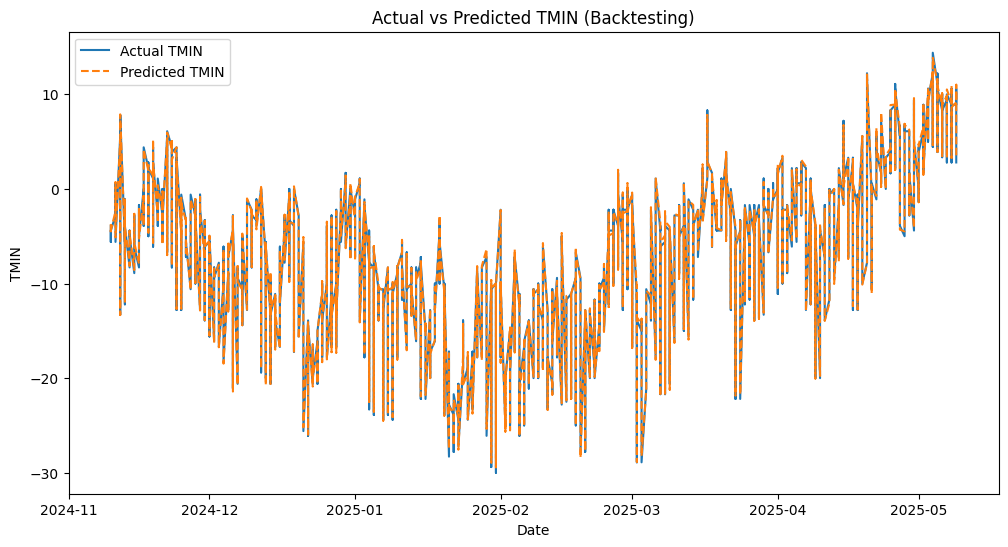

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
# 11. Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(test_data['DATE'], y_test, label='Actual TMIN')
plt.plot(test_data['DATE'], y_pred, label='Predicted TMIN', linestyle='--')
plt.xlabel('Date')
plt.ylabel('TMIN')
plt.title('Actual vs Predicted TMIN (Backtesting)')
plt.legend()
plt.show()

"The time series plot demonstrates that the model closely follows actual minimum temperature variations across the unseen test period, confirming strong generalization to new temporal patterns."

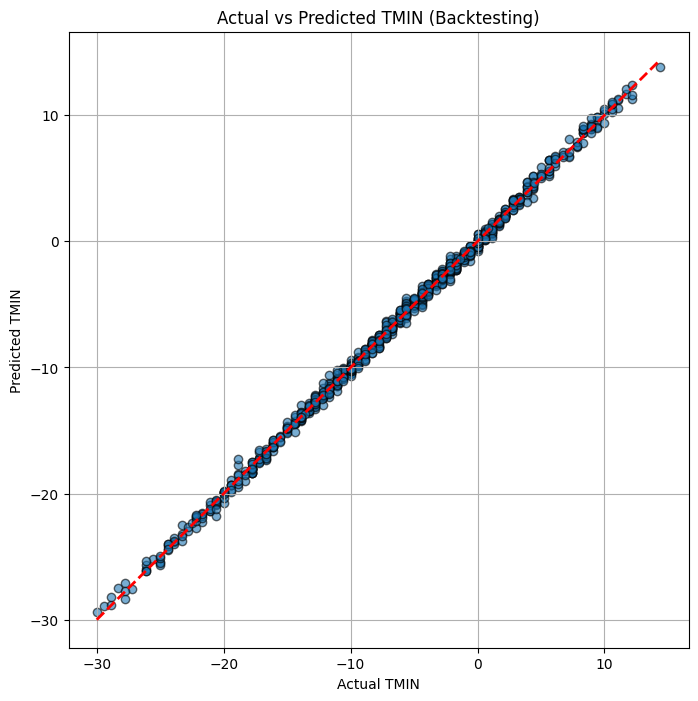

In [19]:
# Scatter plot: Actual vs Predicted TMIN
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')

# Plot perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel('Actual TMIN')
plt.ylabel('Predicted TMIN')
plt.title('Actual vs Predicted TMIN (Backtesting)')
plt.grid(True)
plt.show()

"The scatter plot shows near-perfect alignment between actual and predicted TMIN values, indicating the model's ability to capture the temperature patterns with minimal error."

In [23]:
# 10. Save the model
#joblib.dump(final_model, '/workspaces/BlizzardX/Notebooks/models/data/xgboost_tmin_feature_model.pkl')
joblib.dump(final_model, "models/xgboost_tmin_feature_model.pkl")

['models/xgboost_tmin_feature_model.pkl']

### SNOW Model

In [24]:
# Define target
target = 'SNOW'

# Define features (drop non-needed columns)
non_features = ['DATE', target, 'Station_ID', 'NAME', 'Station_Location']
features = [col for col in data.columns if col not in non_features]

In [25]:
# Create Train/Test split based on DATE
cutoff_date = data['DATE'].max() - pd.DateOffset(months=6)

train_data = data[data['DATE'] <= cutoff_date]
test_data = data[data['DATE'] > cutoff_date]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

In [26]:
# Initialize model
xgb_model = xgb.XGBRegressor(random_state=42)

# Define param grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Cross Validation setup
tscv = TimeSeriesSplit(n_splits=5)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Perform grid search
grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [27]:
# Train final model
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

# Predict
y_pred = final_model.predict(X_test)


In [28]:
# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n✅ SNOW Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


✅ SNOW Model Performance:
MAE: 0.80
RMSE: 2.24
MSE: 5.00
R² Score: 1.00


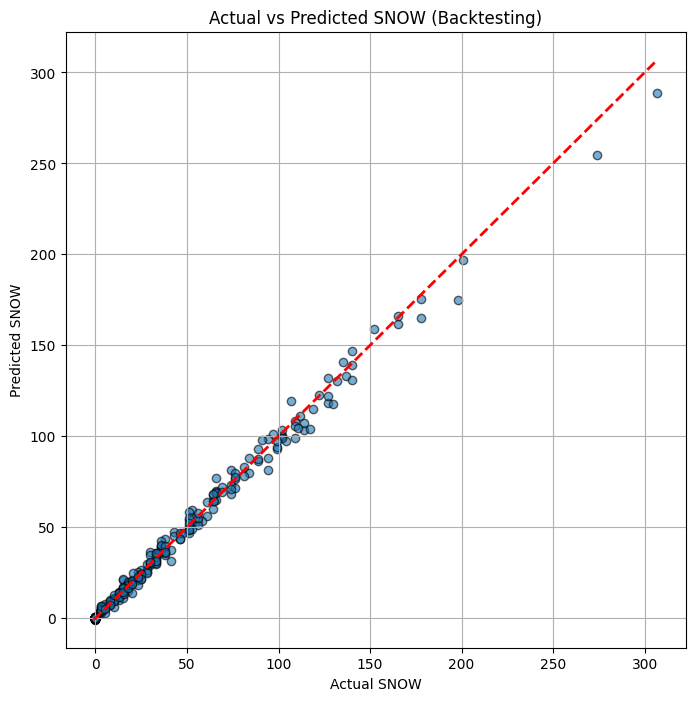

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel('Actual SNOW')
plt.ylabel('Predicted SNOW')
plt.title('Actual vs Predicted SNOW (Backtesting)')
plt.grid(True)
plt.show()


"The scatter plot of Actual vs Predicted SNOW shows a strong linear relationship, with most predictions tightly following the ideal line. Minor deviations occur at extreme snowfall levels, which is expected in real-world data. Overall, the model captures snowfall dynamics with high accuracy."

In [30]:
# Save SNOW model
#joblib.dump(final_model, 'xgboost_snow_model.pkl')
joblib.dump(final_model, "models/xgboost_snow_feature_model.pkl")
print("✅ SNOW model saved successfully as xgboost_snow_model.pkl")

✅ SNOW model saved successfully as xgboost_snow_model.pkl


### SNWD Model

In [31]:
# Define target
target = 'SNWD'

# Define features (drop non-needed columns)
non_features = ['DATE', target, 'Station_ID', 'NAME', 'Station_Location']
features = [col for col in data.columns if col not in non_features]

In [32]:
# Create Train/Test split
cutoff_date = data['DATE'].max() - pd.DateOffset(months=6)

train_data = data[data['DATE'] <= cutoff_date]
test_data = data[data['DATE'] > cutoff_date]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

In [33]:
# Initialize model
xgb_model = xgb.XGBRegressor(random_state=42)

# Define param grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters for SNWD: {grid_search.best_params_}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters for SNWD: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1}


In [34]:
# Train final model
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

# Predict
y_pred = final_model.predict(X_test)

In [35]:
# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n✅ SNWD Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


✅ SNWD Model Performance:
MAE: 0.88
RMSE: 2.34
MSE: 5.47
R² Score: 1.00


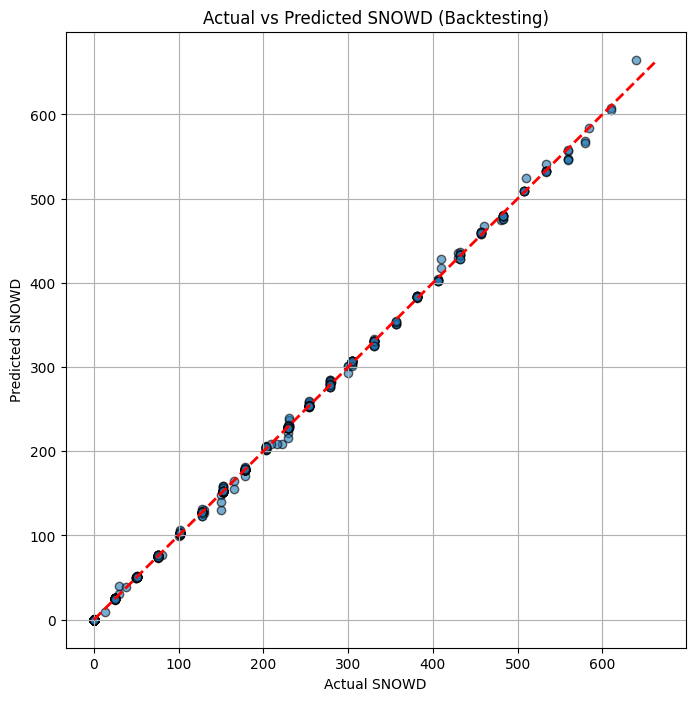

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel('Actual SNOWD')
plt.ylabel('Predicted SNOWD')
plt.title('Actual vs Predicted SNOWD (Backtesting)')
plt.grid(True)
plt.show()

"The scatter plot of Actual vs Predicted SNWD shows that the model performs consistently across low, moderate, and extreme snow depth values, with most predictions closely aligning with the perfect prediction line. Minor deviations occur at very high depths, but overall model performance is exceptionally strong."

In [37]:
# Save SNOW model
joblib.dump(final_model, "models/xgboost_snowd_feature_model.pkl")

['models/xgboost_snowd_feature_model.pkl']

### Cold Event

In [38]:
# Define target
target = 'Cold_Event'

# Define features (drop non-needed columns)
non_features = ['DATE', target, 'Station_ID', 'NAME', 'Station_Location']
features = [col for col in data.columns if col not in non_features]


In [39]:
# Create Train/Test split
cutoff_date = data['DATE'].max() - pd.DateOffset(months=6)

train_data = data[data['DATE'] <= cutoff_date]
test_data = data[data['DATE'] > cutoff_date]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]


In [40]:
# Initialize classifier model
xgb_model = xgb.XGBClassifier(random_state=42)

# Define param grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters for Cold_Event: {grid_search.best_params_}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters for Cold_Event: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1}


In [41]:
# Train final classifier
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

# Predict
y_pred = final_model.predict(X_test)

In [43]:
# Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n✅ Cold Event Classification Performance:")
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)


✅ Cold Event Classification Performance:
Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       688
           1       1.00      0.99      0.99       217

    accuracy                           1.00       905
   macro avg       1.00      0.99      1.00       905
weighted avg       1.00      1.00      1.00       905

Confusion Matrix:
[[688   0]
 [  3 214]]


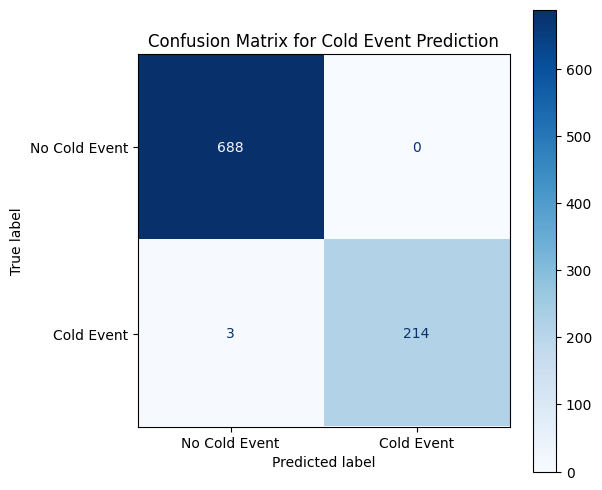

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No Cold Event', 'Cold Event'])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix for Cold Event Prediction')
plt.show()


"The confusion matrix heatmap shows that the Cold Event classifier achieves near-perfect classification, correctly predicting almost all cold and non-cold events. Only a very small number of cold events (3) were misclassified, demonstrating the model's high reliability."

In [45]:
# Save SNOW model
joblib.dump(final_model, "models/xgboost_cold_event_feature_model.pkl")

['models/xgboost_cold_event_feature_model.pkl']